# Alberth std-filtered to SAM3

這個 notebook 複用 `Alberth_pipeline.ipynb` 到 `std_filtered_vid[segment == 0.0] = 0.0`，
接著做 `robust_scale(std_filtered_vid, 1, 99.99)`，再把結果輸出成 JPEG frame 序列，最後直接在 notebook 內測試本地 `SAM3` 的文字提示輸入。

In [41]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from transformers import Sam3Model, Sam3Processor

repo_root = Path.cwd().resolve().parents[1] if Path.cwd().name == "Schlieren" else Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

try:
    import cupy as _cupy  # type: ignore
    _cupy.cuda.runtime.getDeviceCount()
    cp = _cupy
    USING_CUPY = True
except Exception as exc:
    print(f"CuPy unavailable, falling back to NumPy backend: {exc}")
    USING_CUPY = False

    class _NumpyCompat:
        def __getattr__(self, name):
            return getattr(np, name)

        def asarray(self, a, dtype=None):
            return np.asarray(a, dtype=dtype)

        def asnumpy(self, a):
            return np.asarray(a)

    cp = _NumpyCompat()  # type: ignore

from OSCC_postprocessing.cine.functions_videos import load_cine_video
from OSCC_postprocessing.filters.stdfilt import stdfilt
from OSCC_postprocessing.io.async_avi_saver import AsyncAVISaver
from OSCC_postprocessing.utils.scaling import robust_scale

if USING_CUPY:
    from OSCC_postprocessing.rotation.rotate_with_alignment import (
        rotate_video_nozzle_at_0_half_cupy as rotate_video_nozzle_at_0_half_backend,
    )
else:
    from OSCC_postprocessing.rotation.rotate_with_alignment_cpu import (
        rotate_video_nozzle_at_0_half_numpy as rotate_video_nozzle_at_0_half_backend,
    )


def to_numpy(arr):
    return cp.asnumpy(arr) if USING_CUPY else np.asarray(arr)


def export_jpeg_frames(video_u8: np.ndarray, output_dir: Path, jpeg_quality: int = 95) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    params = [int(cv2.IMWRITE_JPEG_QUALITY), int(jpeg_quality)]
    for idx, frame in enumerate(video_u8):
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        frame_path = output_dir / f"{idx:05d}.jpg"
        ok = cv2.imwrite(str(frame_path), frame_bgr, params)
        if not ok:
            raise RuntimeError(f"Failed to write JPEG frame: {frame_path}")


def export_mjpg_avi(video_u8: np.ndarray, output_path: Path, fps: int = 30) -> None:
    video_bgr = np.repeat(video_u8[..., None], 3, axis=-1)
    saver = AsyncAVISaver(max_workers=1, default_codec="MJPG")
    try:
        saver.save(output_path, video_bgr, fps=fps, codec="MJPG", is_color=True, auto_normalize=False)
        saver.wait()
    finally:
        saver.shutdown(wait=False)


In [42]:
file = Path(r"G:\MeOH_test\Schlieren\T55_Schlieren Cam_3.cine")
json_file = Path(r"G:\MeOH_test\Schlieren\config.json")
out_dir = Path(r"G:\MeOH_test\Schlieren\Processed_Results")

video_bits = 12
std_filt_ksize = 21
jpeg_quality = 95
fps = 30
frame_limit = None

sam3_model_dir = repo_root / ".models" / "sam3_hf"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"repo_root: {repo_root}")
print(f"device: {device}")
print(f"sam3_model_dir exists: {sam3_model_dir.exists()} -> {sam3_model_dir}")

repo_root: C:\Users\Jiang\Documents\Mie_Postprocessing_Py
device: cuda
sam3_model_dir exists: True -> C:\Users\Jiang\Documents\Mie_Postprocessing_Py\.models\sam3_hf


In [43]:
brightness_levels = float(2**video_bits)
video = load_cine_video(str(file), frame_limit=frame_limit).astype(np.float32) / brightness_levels
F, H, W = video.shape

with open(json_file, "r", encoding="utf-8") as handle:
    data = json.load(handle)
    offset = float(data["offset"])
    centre = (float(data["centre_x"]), float(data["centre_y"]))

print(f"video shape: {video.shape}")
print(f"offset: {offset}")
print(f"centre: {centre}")

Video Info - Width: 768, Height: 768, Frames: 401
video shape: (401, 768, 768)
offset: -45.0
centre: (191.0, 108.0)


In [44]:
out_shape = (H // 2, H)

segment, _, _ = rotate_video_nozzle_at_0_half_backend(
    video,
    centre,
    offset,
    interpolation="nearest",
    border_mode="constant",
    out_shape=out_shape,
)

segment = cp.asarray(robust_scale(segment, 1, 99.9), dtype=cp.float32)
print(f"segment shape: {tuple(int(v) for v in segment.shape)}")

segment shape: (401, 384, 768)


In [45]:
std_filtered_vid = stdfilt(segment, ksize=std_filt_ksize)
std_filtered_vid[segment == 0.0] = 0.0

std_filtered_normalized = cp.asarray(robust_scale(std_filtered_vid, 1, 99.99), dtype=cp.float32)
std_filtered_normalized_np = to_numpy(std_filtered_normalized).astype(np.float32, copy=False)
std_filtered_normalized_u8 = (std_filtered_normalized_np * 255.0).round().astype(np.uint8)

experiment_root = out_dir / f"{file.stem}_std_filtered_jpeg"
jpeg_dir = experiment_root / "jpeg_frames"
npy_path = experiment_root / "std_filtered_normalized.npy"
avi_path = experiment_root / "std_filtered_normalized_mjpg.avi"
experiment_root.mkdir(parents=True, exist_ok=True)

np.save(npy_path, std_filtered_normalized_np)
export_jpeg_frames(std_filtered_normalized_u8, jpeg_dir, jpeg_quality=jpeg_quality)
export_mjpg_avi(std_filtered_normalized_u8, avi_path, fps=fps)

print(f"saved numpy: {npy_path}")
print(f"saved jpeg frames for SAM3: {jpeg_dir}")
print(f"saved mjpg avi: {avi_path}")

saved numpy: G:\MeOH_test\Schlieren\Processed_Results\T55_Schlieren Cam_3_std_filtered_jpeg\std_filtered_normalized.npy
saved jpeg frames for SAM3: G:\MeOH_test\Schlieren\Processed_Results\T55_Schlieren Cam_3_std_filtered_jpeg\jpeg_frames
saved mjpg avi: G:\MeOH_test\Schlieren\Processed_Results\T55_Schlieren Cam_3_std_filtered_jpeg\std_filtered_normalized_mjpg.avi


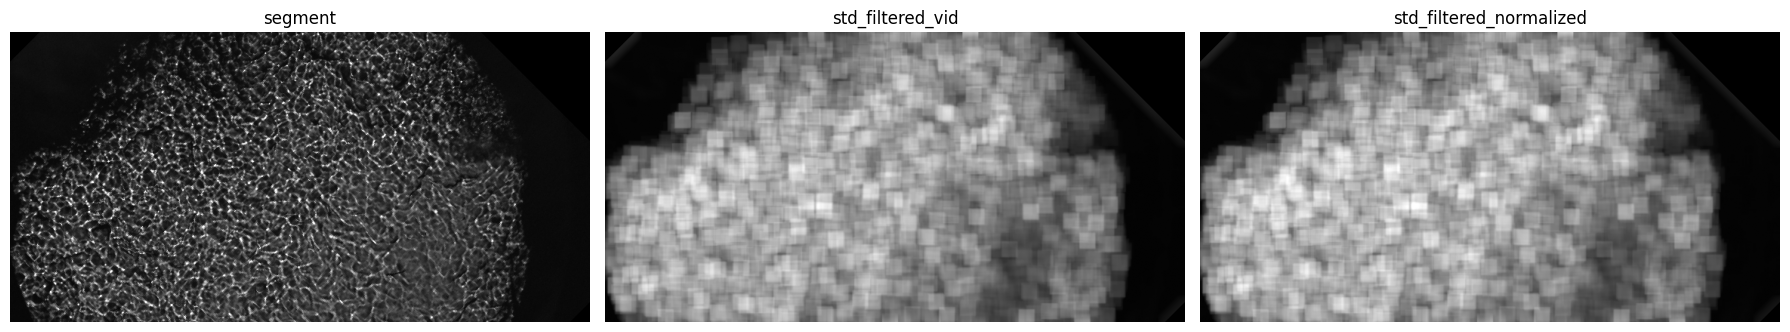

In [46]:
frame_idx = 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(to_numpy(segment[frame_idx]), cmap="gray")
axes[0].set_title("segment")
axes[1].imshow(to_numpy(std_filtered_vid[frame_idx]), cmap="gray")
axes[1].set_title("std_filtered_vid")
axes[2].imshow(std_filtered_normalized_np[frame_idx], cmap="gray", vmin=0.0, vmax=1.0)
axes[2].set_title("std_filtered_normalized")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## SAM3 prompt試驗

下面先把 `std_filtered_normalized` 的單幀轉成偽 RGB，再交給 `SAM3` image API。
這裡先測文字提示詞，後面如果效果差，再改成 box / point / mask prompt。

In [47]:
model = Sam3Model.from_pretrained(sam3_model_dir).to(device)
processor = Sam3Processor.from_pretrained(sam3_model_dir)
print("SAM3 loaded")

Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 10676.34it/s]


SAM3 loaded


In [48]:
frame_idx = 50
prompt = "black blob"

frame_u8 = std_filtered_normalized_u8[frame_idx]
frame_rgb = np.repeat(frame_u8[..., None], 3, axis=-1)
sam3_image = Image.fromarray(frame_rgb, mode="RGB")


def run_sam3_text_prompt(image: Image.Image, text_prompt: str, threshold: float = 0.5, mask_threshold: float = 0.5):
    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=threshold,
        mask_threshold=mask_threshold,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]
    return results


results = run_sam3_text_prompt(sam3_image, prompt)
print(f"prompt: {prompt}")
print(f"detections: {len(results['masks'])}")
results

prompt: black blob
detections: 0


{'scores': tensor([], device='cuda:0'),
 'boxes': tensor([], device='cuda:0', size=(0, 4)),
 'masks': tensor([], device='cuda:0', size=(0, 288, 288), dtype=torch.int64)}

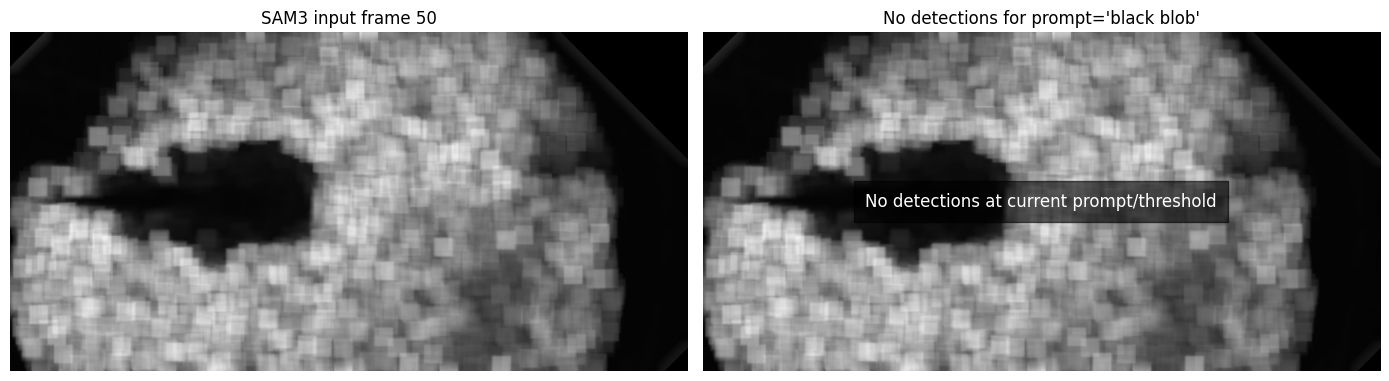

In [49]:
from matplotlib.patches import Rectangle

img = np.array(sam3_image)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img)
axes[0].set_title(f"SAM3 input frame {frame_idx}")
axes[0].axis("off")

axes[1].imshow(img)
num_masks = len(results["masks"])
if num_masks == 0:
    axes[1].set_title(f"No detections for prompt='{prompt}'")
    axes[1].text(
        0.5,
        0.5,
        "No detections at current prompt/threshold",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
        color="white",
        fontsize=12,
        bbox=dict(facecolor="black", alpha=0.6, pad=8),
    )
else:
    colors = plt.cm.tab10(np.linspace(0, 1, num_masks))
    for mask, box, score, color in zip(results["masks"], results["boxes"], results["scores"], colors):
        mask_np = mask.detach().cpu().numpy().astype(bool)
        color_rgb = np.array(color[:3])
        overlay = np.zeros((*mask_np.shape, 4), dtype=np.float32)
        overlay[mask_np, :3] = color_rgb
        overlay[mask_np, 3] = 0.35
        axes[1].imshow(overlay)
        x0, y0, x1, y1 = box.detach().cpu().tolist()
        axes[1].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=color_rgb, linewidth=2))
        axes[1].text(
            x0,
            max(y0 - 6, 0),
            f"score={float(score):.3f}",
            color="white",
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.6, pad=2),
        )
    axes[1].set_title(f"SAM3 detections for prompt='{prompt}'")

axes[1].axis("off")
plt.tight_layout()
plt.show()

In [50]:
candidate_prompts = [
    "moving black blob",
    "jet plume",
    "foreground plume",
    "fluid jet",
    "smoke plume",
    "dark foreground object",
]

prompt_summary = []
for text_prompt in candidate_prompts:
    prompt_results = run_sam3_text_prompt(sam3_image, text_prompt)
    prompt_summary.append(
        {
            "prompt": text_prompt,
            "detections": int(len(prompt_results["masks"])),
            "scores": [float(v) for v in prompt_results["scores"].detach().cpu().tolist()],
        }
    )

prompt_summary

[{'prompt': 'moving black blob',
  'detections': 1,
  'scores': [0.6004434823989868]},
 {'prompt': 'jet plume', 'detections': 0, 'scores': []},
 {'prompt': 'foreground plume', 'detections': 0, 'scores': []},
 {'prompt': 'fluid jet', 'detections': 0, 'scores': []},
 {'prompt': 'smoke plume', 'detections': 0, 'scores': []},
 {'prompt': 'dark foreground object', 'detections': 0, 'scores': []}]

In [ ]:
"""
Old per-frame SAM3 image prompt path kept for reference. Disabled in favor of the official video predictor below.

sam3_video_prompt = "moving black blob"
sam3_video_threshold = 0.5
sam3_video_mask_threshold = 0.5
sam3_video_fps = fps
sam3_video_max_frames = None  # set to e.g. 120 for a faster preview
sam3_video_morph_kernel_size = 3


def sam3_best_mask_for_frame(
    frame_u8: np.ndarray,
    text_prompt: str,
    threshold: float = 0.5,
    mask_threshold: float = 0.5,
    morph_kernel_size: int = 0,
) -> tuple[np.ndarray, float | None]:
    frame_rgb = np.repeat(frame_u8[..., None], 3, axis=-1)
    image = Image.fromarray(frame_rgb, mode="RGB")
    frame_results = run_sam3_text_prompt(
        image,
        text_prompt,
        threshold=threshold,
        mask_threshold=mask_threshold,
    )

    if len(frame_results["masks"]) == 0:
        return np.zeros(frame_u8.shape, dtype=bool), None

    best_idx = int(torch.argmax(frame_results["scores"]).detach().cpu().item())
    score = float(frame_results["scores"][best_idx].detach().cpu().item())
    mask = frame_results["masks"][best_idx].detach().cpu().numpy().astype(np.uint8)

    if morph_kernel_size and morph_kernel_size > 1:
        kernel = np.ones((morph_kernel_size, morph_kernel_size), dtype=np.uint8)
        mask = cv2.morphologyEx(mask * 255, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = mask > 0
    else:
        mask = mask.astype(bool)

    return mask, score


def build_sam3_foreground_frames(
    video_u8: np.ndarray,
    text_prompt: str,
    threshold: float = 0.5,
    mask_threshold: float = 0.5,
    max_frames: int | None = None,
    morph_kernel_size: int = 0,
) -> tuple[np.ndarray, list[float | None]]:
    total_frames = int(video_u8.shape[0]) if max_frames is None else min(int(max_frames), int(video_u8.shape[0]))
    foreground_frames = []
    scores = []

    for idx in range(total_frames):
        frame_u8 = video_u8[idx]
        mask, score = sam3_best_mask_for_frame(
            frame_u8,
            text_prompt,
            threshold=threshold,
            mask_threshold=mask_threshold,
            morph_kernel_size=morph_kernel_size,
        )

        foreground = np.zeros_like(frame_u8)
        foreground[mask] = frame_u8[mask]
        foreground_bgr = cv2.cvtColor(foreground, cv2.COLOR_GRAY2BGR)

        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(foreground_bgr, contours, -1, (0, 255, 0), 1)
        score_text = "none" if score is None else f"{score:.3f}"
        cv2.putText(
            foreground_bgr,
            f"frame={idx} score={score_text} q/esc=quit",
            (10, 24),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

        foreground_frames.append(foreground_bgr)
        scores.append(score)

        if (idx + 1) % 25 == 0 or idx + 1 == total_frames:
            print(f"segmented {idx + 1}/{total_frames} frames")

    return np.stack(foreground_frames, axis=0), scores


def play_video_cv2(frames: np.ndarray, title: str = "SAM3 foreground", fps: int = 30, scale: float = 1.0) -> None:
    delay_ms = max(1, int(round(1000 / fps)))
    cv2.namedWindow(title, cv2.WINDOW_NORMAL)
    try:
        for frame in frames:
            frame_show = frame
            if scale != 1.0:
                frame_show = cv2.resize(frame_show, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
            cv2.imshow(title, frame_show)
            key = cv2.waitKey(delay_ms) & 0xFF
            if key in (27, ord("q")):
                break
    finally:
        cv2.destroyWindow(title)
        cv2.waitKey(1)


sam3_foreground_frames, sam3_foreground_scores = build_sam3_foreground_frames(
    std_filtered_normalized_u8,
    sam3_video_prompt,
    threshold=sam3_video_threshold,
    mask_threshold=sam3_video_mask_threshold,
    max_frames=sam3_video_max_frames,
    morph_kernel_size=sam3_video_morph_kernel_size,
)
"""


'\nOld per-frame SAM3 image prompt path kept for reference. Disabled in favor of the official video predictor below.\n\nsam3_video_prompt = "moving black blob"\nsam3_video_threshold = 0.5\nsam3_video_mask_threshold = 0.5\nsam3_video_fps = fps\nsam3_video_max_frames = None  # set to e.g. 120 for a faster preview\nsam3_video_morph_kernel_size = 3\n\n\ndef sam3_best_mask_for_frame(\n    frame_u8: np.ndarray,\n    text_prompt: str,\n    threshold: float = 0.5,\n    mask_threshold: float = 0.5,\n    morph_kernel_size: int = 0,\n) -> tuple[np.ndarray, float | None]:\n    frame_rgb = np.repeat(frame_u8[..., None], 3, axis=-1)\n    image = Image.fromarray(frame_rgb, mode="RGB")\n    frame_results = run_sam3_text_prompt(\n        image,\n        text_prompt,\n        threshold=threshold,\n        mask_threshold=mask_threshold,\n    )\n\n    if len(frame_results["masks"]) == 0:\n        return np.zeros(frame_u8.shape, dtype=bool), None\n\n    best_idx = int(torch.argmax(frame_results["scores"]).

: 

In [ ]:

import os
import shlex
import subprocess

sam3_video_prompt = "moving black blob"
sam3_video_frame_index = frame_idx
sam3_video_fps = fps
sam3_video_mask_keep_threshold = 0.5
sam3_video_max_frames = None
sam3_video_checkpoint = repo_root / ".models" / "sam3_hf" / "sam3.pt"
sam3_video_export_root = experiment_root / "sam3_video_export_moving_black_blob"
sam3_video_script = repo_root / "scripts" / "export_sam3_video_results.py"

# This uses the official video session API through scripts/export_sam3_video_results.py.
# Use jpeg_dir instead if the local OpenCV build cannot decode this AVI codec.
sam3_video_resource_path = avi_path

sam3_official_root = repo_root / "third_party" / "sam3_official"
sam3_env = os.environ.copy()
sam3_env.setdefault("USE_PERFLIB", "0")
if sam3_official_root.exists():
    existing_pythonpath = sam3_env.get("PYTHONPATH", "")
    sam3_env["PYTHONPATH"] = str(sam3_official_root) + (os.pathsep + existing_pythonpath if existing_pythonpath else "")


def to_wsl_path(path: Path) -> str:
    path = Path(path).resolve()
    if path.drive:
        drive = path.drive[:1].lower()
        return f"/mnt/{drive}/" + "/".join(path.parts[1:])
    return path.as_posix()


sam3_video_args = [
    "--video-path",
    str(sam3_video_resource_path),
    "--checkpoint",
    str(sam3_video_checkpoint),
    "--version",
    "sam3",
    "--prompt",
    sam3_video_prompt,
    "--frame-index",
    str(sam3_video_frame_index),
    "--output-root",
    str(sam3_video_export_root),
    "--save-format",
    "all",
    "--fps",
    str(sam3_video_fps),
    "--mask-threshold",
    str(sam3_video_mask_keep_threshold),
]
if sam3_video_max_frames is not None:
    sam3_video_args.extend(["--max-frames", str(sam3_video_max_frames)])

if os.name == "nt":
    repo_root_wsl = to_wsl_path(repo_root)
    sam3_video_args_wsl = sam3_video_args.copy()
    for flag, path_value in {
        "--video-path": sam3_video_resource_path,
        "--checkpoint": sam3_video_checkpoint,
        "--output-root": sam3_video_export_root,
    }.items():
        value_index = sam3_video_args_wsl.index(flag) + 1
        sam3_video_args_wsl[value_index] = to_wsl_path(path_value)

    inner_cmd = " ".join(
        shlex.quote(part)
        for part in [
            "./scripts/run_in_sam3_wsl_env.sh",
            "python",
            "scripts/export_sam3_video_results.py",
            *sam3_video_args_wsl,
        ]
    )
    cmd = ["wsl.exe", "bash", "-lc", f"cd {shlex.quote(repo_root_wsl)} && {inner_cmd}"]
    cmd_env = None
else:
    cmd = [sys.executable, str(sam3_video_script), *sam3_video_args]
    cmd_env = sam3_env

print("Running official SAM3 video predictor:")
print(" ".join(f'"{part}"' if " " in part else part for part in cmd))
completed = subprocess.run(
    cmd,
    env=cmd_env,
    text=True,
    capture_output=True,
    encoding="utf-8",
    errors="replace",
)
if completed.stdout:
    print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
completed.check_returncode()


def build_foreground_from_sam3_video_masks(video_u8: np.ndarray, mask_dir: Path) -> np.ndarray:
    foreground_frames = []
    for idx, frame_u8 in enumerate(video_u8):
        mask_path = mask_dir / f"{idx:05d}.png"
        if mask_path.exists():
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) > 0
        else:
            mask = np.zeros(frame_u8.shape, dtype=bool)

        frame_bgr = cv2.cvtColor(frame_u8, cv2.COLOR_GRAY2BGR)
        foreground_bgr = np.zeros_like(frame_bgr)
        foreground_bgr[mask] = frame_bgr[mask]

        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(foreground_bgr, contours, -1, (0, 255, 0), 1)
        cv2.putText(
            foreground_bgr,
            f"frame={idx} q/esc=quit",
            (10, 24),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        foreground_frames.append(foreground_bgr)

    return np.stack(foreground_frames, axis=0)


def play_video_cv2(frames: np.ndarray, title: str = "SAM3 video foreground", fps: int = 30, scale: float = 1.0) -> None:
    delay_ms = max(1, int(round(1000 / fps)))
    cv2.namedWindow(title, cv2.WINDOW_NORMAL)
    try:
        for frame in frames:
            frame_show = frame
            if scale != 1.0:
                frame_show = cv2.resize(frame_show, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
            cv2.imshow(title, frame_show)
            key = cv2.waitKey(delay_ms) & 0xFF
            if key in (27, ord("q")):
                break
    finally:
        cv2.destroyWindow(title)
        cv2.waitKey(1)


sam3_foreground_frames = build_foreground_from_sam3_video_masks(
    std_filtered_normalized_u8,
    sam3_video_export_root / "mask_png",
)
play_video_cv2(sam3_foreground_frames, fps=sam3_video_fps)


In [55]:

play_video_cv2(sam3_foreground_frames, fps=sam3_video_fps)
